In [1]:
import typing
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa import stattools

from transportation_models.utils.validation import validate_timestamp_dtype

# Example filename
filename = '/Users/robstallman/Library/CloudStorage/OneDrive-UCB-O365/Data/PeMS_Data/csv_files/400716.csv'

station_id = "400716"
df = pd.read_csv(filename)
df = validate_timestamp_dtype(df)
df.head()


,timestamp,station,district,freeway,direction_of_travel,lane_type,station_length,samples,pct_observed,total_flow_[veh/5-min],...,good_samples_lane_7,flow_lane_7,avg_occupancy_lane_7,avg_speed_lane_7,observed_lane_7,good_samples_lane_8,flow_lane_8,avg_occupancy_lane_8,avg_speed_lane_8,observed_lane_8
0,2024-01-01 00:00:00,400716,4,880,N,ML,0.535,40,100,96.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
1,2024-01-01 00:05:00,400716,4,880,N,ML,0.535,40,100,60.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
2,2024-01-01 00:10:00,400716,4,880,N,ML,0.535,40,100,77.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
3,2024-01-01 00:15:00,400716,4,880,N,ML,0.535,40,100,104.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
4,2024-01-01 00:20:00,400716,4,880,N,ML,0.535,40,100,127.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0


<Axes: xlabel='timestamp'>

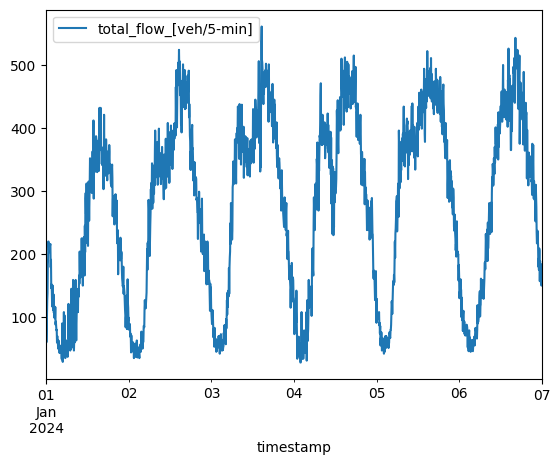

In [164]:
ts_start = pd.Timestamp(year=2024, month=1, day=1)
ts_end = pd.Timestamp(year=2024, month=1, day=7)
df.loc[(df['timestamp'] <= ts_end), ['timestamp', 'total_flow_[veh/5-min]']].set_index('timestamp').plot()

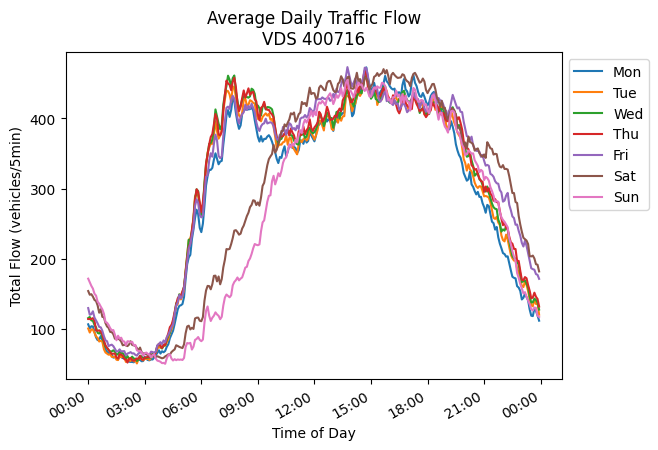

In [2]:
def get_daily_average(df: pd.DataFrame, station_id: str, metric: str = 'total_flow_[veh/5-min]', include_plot: bool = True, plot_filename: typing.Optional[str] = None):
    # Validate the timestamp column
    df = validate_timestamp_dtype(df)

    # Generate some derived temporal qualities from the timestamp
    df['weekday'] = df['timestamp'].dt.weekday
    df['5min_block'] = (df['timestamp'].dt.minute / 60) + (df['timestamp'].dt.hour)
    df['15min_block'] = (df['timestamp'].dt.floor('15min').dt.minute / 60) + (df['timestamp'].dt.hour)

    # Pick out relevant columns from the df
    df = df.loc[:,["5min_block", "weekday", metric]]

    # Calculate the average for the metric for each (t,weekday) index
    daily_average_df = df.groupby(["5min_block", "weekday"]).mean().unstack('weekday')

    # Drop the metric index and map the weekday integers onto days of the week
    daily_average_df.columns = daily_average_df.columns.get_level_values('weekday').map(
        {
            0: 'Mon',
            1: 'Tue',
            2: 'Wed',
            3: 'Thu',
            4: 'Fri',
            5: 'Sat',
            6: 'Sun'
        })

    # Translate the time information in '5min_block' back into a timestamp & use this as the index
    daily_average_df.reset_index(inplace=True)
    daily_average_df['timestamp'] = pd.to_timedelta(daily_average_df["5min_block"], unit="h").apply(lambda x: (pd.Timestamp("1970-01-01") + x))
    daily_average_df.set_index('timestamp', inplace=True)
    daily_average_df.drop('5min_block', inplace=True, axis=1)

    # Generate a plot
    if include_plot:
        ax = daily_average_df.plot()
        ax.legend(loc='upper left', bbox_to_anchor=(1,1))
        ax.set_xlabel("Time of Day")
        ax.set_ylabel("Total Flow (vehicles/5min)")
        ax.set_title(f"Average Daily Traffic Flow\nVDS {station_id}")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        if plot_filename is not None:
            plt.savefig(plot_filename)
    
    return daily_average_df

daily_average_df = get_daily_average(df, station_id=station_id)

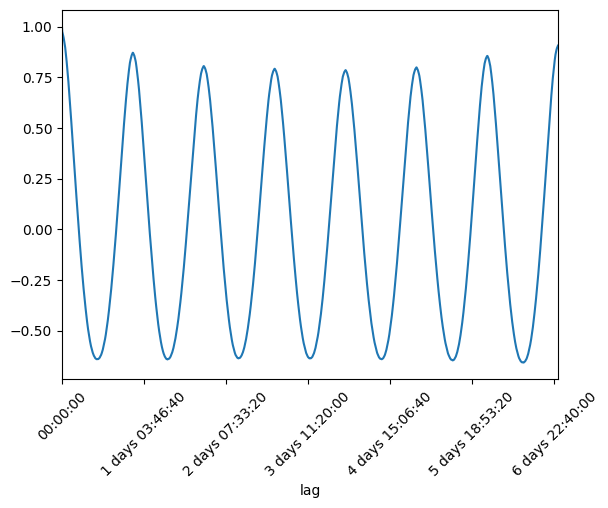

In [ ]:
# Autocorrelation
# This assumes that the timeseries is weakly stationary, which we don't necessarily want to do yet.
# We should start with a heatmap of autocorrelation as a function of (s,t)
ndays = 7
periods = ndays * 24 * 12
nlags = periods-1
acovf = stattools.acf(df['total_flow_[veh/5-min]'], nlags=nlags, missing='conservative', fft=True, adjusted=True)
times = pd.date_range(start='00:00:00', periods=periods, freq='5min')
time_lags = times - times[0]
stats_df = pd.DataFrame(data={'time':times, 'lag':time_lags, 'acovf':acovf})
ax = stats_df.set_index('lag').loc[:,'acovf'].plot()
ax.tick_params(axis='x', labelrotation=45)
